## Evolution of entrainment speed

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Use given style and color maps
from colors import colors7 as colors

plt.style.use("james2026lock.mplstyle")

# constants
rho_water = 998.2  # Freshwater density [kg/m³]
rho_bent = 2277  # Wetted bentonite density [kg/m³]
h0 = 0.25  # initial water height [m]
l0 = 0.27  # mixing chamber length [m]
v0 = h0 * l0
a_thresh = 0.06  # m/s² for example (below this velocity taken as roughly constant)

# load experiment table
metadata = pd.read_csv("../../data/metadata/metadata.csv")
folder = "../../data/datafiles"

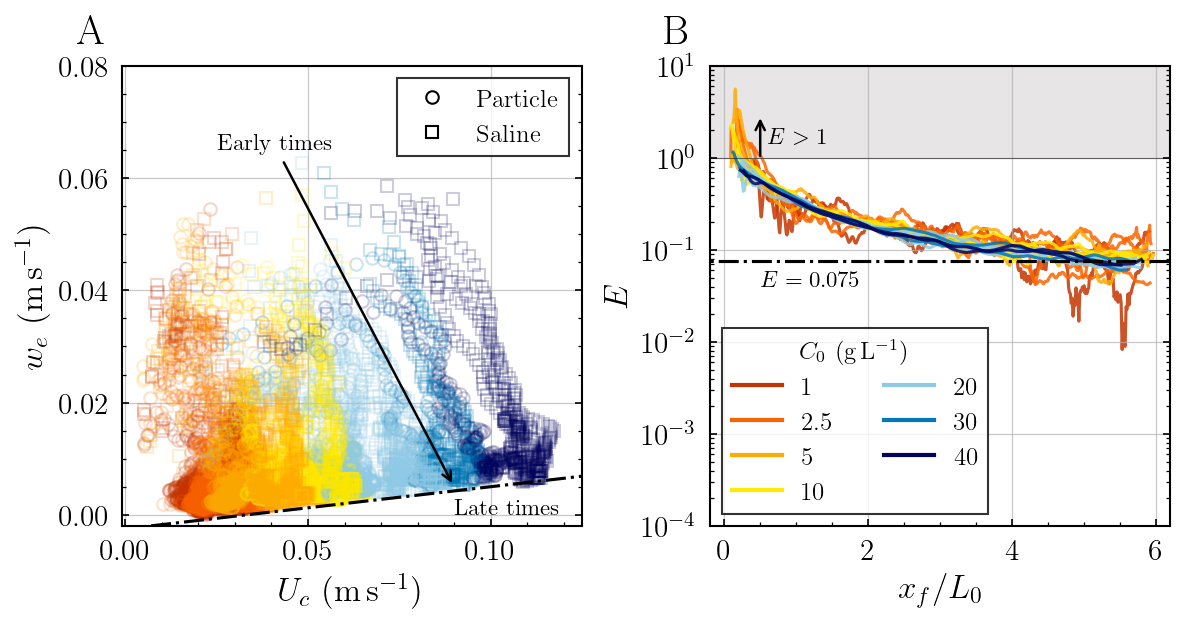

In [3]:
WINDOW = 120  # smoothing window for moving average
SKIP = 10  # downsampling step for scatter plots
E_REF = 0.075  # reference entrainment coefficient


def moving_average(a, w):
    """Smooth array a with a boxcar window of width w."""
    return np.convolve(a, np.ones(w) / w, mode="valid")


fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for _, row in metadata.iterrows():
    data = np.load(f"{folder}/{row.exp_code}.npy", allow_pickle=True).item()
    fronts = np.abs(data["front_m"])
    areas = np.abs(data["area_m2"])
    times = np.abs(data["time_s"])

    # Smooth front and area; align time array to match smoothed length
    x = moving_average(fronts, WINDOW)
    A = moving_average(areas, WINDOW)
    t = times[WINDOW - 1 :]

    # Compute front velocity, area gradient, and entrainment velocity
    dt = np.diff(t)
    U = np.diff(x) / dt  # front velocity
    dAdx = np.diff(A) / np.diff(x)  # area gradient w.r.t. front position
    w_e = (U / x[1:]) * dAdx  # entrainment velocity w_e = (U/x) * dA/dx

    idx = np.arange(0, len(w_e), SKIP)  # downsampled indices
    c = colors[int(row.exp_code[2]) - 1]
    m = "s" if row.type == "saline" else "o"

    # Panel 0: w_e vs U for all experiments
    ax[0].plot(
        U[idx],
        w_e[idx],
        marker=m,
        linestyle="",
        color=c,
        markeredgecolor=c,
        markerfacecolor="none",
        markeredgewidth=1,
        alpha=0.2,
        label=row.exp_code,
    )

    # Panel 1: entrainment coefficient E = w_e/U vs normalised front position (particle only)
    if row.type == "part":
        ax[1].plot(
            x[idx] / l0,
            w_e[idx] / U[idx],
            color=c,
            ls="-",
            zorder=int(row.exp_code[2]) - 1,
            alpha=0.85,
        )

# --- Panel 0: example reference slope ---
x_line = np.linspace(-0.02, 0.14, 100)
ax[0].plot(x_line, E_REF * (x_line + 0.1) - 0.01, "k-.", label="Example slope")
ax[0].set(
    xlabel="$U_c$ (m\\,s$^{-1}$)",
    ylabel="$w_e$ (m\\,s$^{-1}$)",
    xlim=[-0.001, 0.125],
    ylim=[-0.002, 0.08],
)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        label="Particle",
        markeredgecolor="k",
        markerfacecolor="none",
        markeredgewidth=1,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        label="Saline",
        markeredgecolor="k",
        markerfacecolor="none",
        markeredgewidth=1,
    ),
]
ax[0].legend(handles=legend_elements, loc="upper right")

# --- Panel 0 annotations: early/late times with arrow ---
ax[0].annotate("Late times", xy=(0.09, 0), fontsize=11)
ax[0].annotate(
    "Early times",
    xy=(0.09, 0.005),
    xytext=(0.025, 0.065),
    arrowprops=dict(arrowstyle="->", color="k", lw=1.2),
    fontsize=11,
)


# --- Panel 1: reference entrainment coefficient and shaded E > 1 region ---
ax[1].hlines(E_REF, -1, 7, colors="k", linestyles="-.", label=f"E = {E_REF}", zorder=8)
ax[1].hlines(1, -1, 7, colors="k", linestyles="-", linewidth=0.5, alpha=0.5, zorder=8)
ax[1].axhspan(1, 60, color="#e7e5e5", alpha=1, zorder=0)
ax[1].set(
    xlabel="$x_f/L_0$", ylabel="$E$", yscale="log", xlim=[-0.2, 6.2], ylim=[0.0001, 10]
)
ax[1].annotate(
    "",
    xy=(0.5, 3),
    xytext=(0.5, 0.95),
    arrowprops=dict(arrowstyle="->", color="k", lw=1.2),
    fontsize=11,
)
ax[1].text(
    0.6,
    1.4,
    "$E>1$",
    fontsize=11,
)

ax[1].text(
    0.5,
    4e-2,
    "$E=0.075$",
    fontsize=11,
)

# Get unique C0 values in ascending order from particle experiments
c0_values = sorted(metadata[metadata["type"] == "part"]["C0"].unique())

legend_elements = [
    Line2D([0], [0], color=colors[i], linewidth=2, label=f"{c0:.2g}")
    for i, c0 in enumerate(c0_values)
]
ax[1].legend(
    handles=legend_elements, title="$C_0$ (g\\,L$^{-1}$)", loc="lower left", ncols=2
)

# ============== Labels ==============
for axis, label in zip(ax, ["A", "B"]):
    axis.set_box_aspect(1)
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../figures/figure_13.png", bbox_inches="tight", dpi=300)
plt.show()